# 05 — Análise de rede droga-droga

Construímos um grafo onde:
- **Nós:** medicamentos (top-200 por frequência de reporte)
- **Arestas:** co-reporte no mesmo caso
- **Peso:** número de casos em que ambas aparecem juntas

## Perguntas que respondemos
1. Quais medicamentos são *centrais* (aparecem com muitos outros)?
2. Existem **comunidades de drogas** (Louvain)? Refletem classes terapêuticas?
3. Quais pares têm co-reporte excepcionalmente alto?

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from src.preprocess import normalize_drug_table
from src.network import (
    top_drugs, build_cooccurrence, build_graph,
    centrality_metrics, detect_communities,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "reports" / "figures"

## 1. Construir o grafo

In [2]:
drug = normalize_drug_table(pd.read_parquet(PROCESSED / "drug_2023.parquet"))
print(f"Linhas drug normalizadas: {len(drug):,}")

keep = top_drugs(drug, n=200)
print(f"Top 200 drogas selecionadas para o grafo")
print(f"Cobertura: {drug['drug_norm'].isin(keep).mean()*100:.1f}% das linhas")

Linhas drug normalizadas: 7,470,835


Top 200 drogas selecionadas para o grafo


Cobertura: 61.9% das linhas


In [3]:
%time edges = build_cooccurrence(drug, keep, min_coreport=100)
print(f"\nArestas (co-reporte >= 100): {len(edges):,}")
edges.head(10)

CPU times: total: 26.3 s
Wall time: 26.5 s

Arestas (co-reporte >= 100): 10,161


,source,target,weight
0,ACETAMINOPHEN,DIPHENHYDRAMINE,11093
1,ACETAMINOPHEN HYDROCODONE BITARTRATE,ACETAMINOPHEN OXYCODONE,10534
2,PREDNISONE,RITUXIMAB,10379
3,METHOTREXATE,PREDNISONE,9668
4,CYCLOPHOSPHAMIDE,DOXORUBICIN,9552
5,FOLIC ACID,METHOTREXATE,9085
6,CYCLOPHOSPHAMIDE,VINCRISTINE,8683
7,ACETAMINOPHEN,PREDNISONE,8126
8,ACETAMINOPHEN,PANTOPRAZOLE,7830
9,CYCLOPHOSPHAMIDE,RITUXIMAB,7791


In [4]:
g = build_graph(edges)
print(f"Grafo: {g.number_of_nodes()} nós, {g.number_of_edges()} arestas")
print(f"Densidade: {nx.density(g):.4f}")
print(f"Componente principal: {len(max(nx.connected_components(g), key=len))} nós")

Grafo: 199 nós, 10161 arestas
Densidade: 0.5158
Componente principal: 199 nós


## 2. Centralidade — quais drogas são *hubs*?

In [5]:
%time central = centrality_metrics(g)
central.head(15).round(4)

CPU times: total: 2.55 s
Wall time: 2.57 s


,drug,degree_w,eigenvector,betweenness,clustering
0,ACETAMINOPHEN,369481,0.2873,0.0010,0.0662
1,PREDNISONE,317515,0.2436,0.0006,0.0635
2,PANTOPRAZOLE,254020,0.2045,0.0031,0.0536
3,ASPIRIN,245935,0.1993,0.0029,0.0513
4,CHOLECALCIFEROL,241080,0.1954,0.0019,0.0502
5,LEVOTHYROXINE,228904,0.1828,0.0015,0.0478
6,METHOTREXATE,202946,0.1664,0.0115,0.0533
7,ALBUTEROL,204242,0.1624,0.0093,0.0514
8,AMLODIPINE BESYLATE,186598,0.1531,0.0030,0.0432
9,FUROSEMIDE,179415,0.1476,0.0007,0.0481


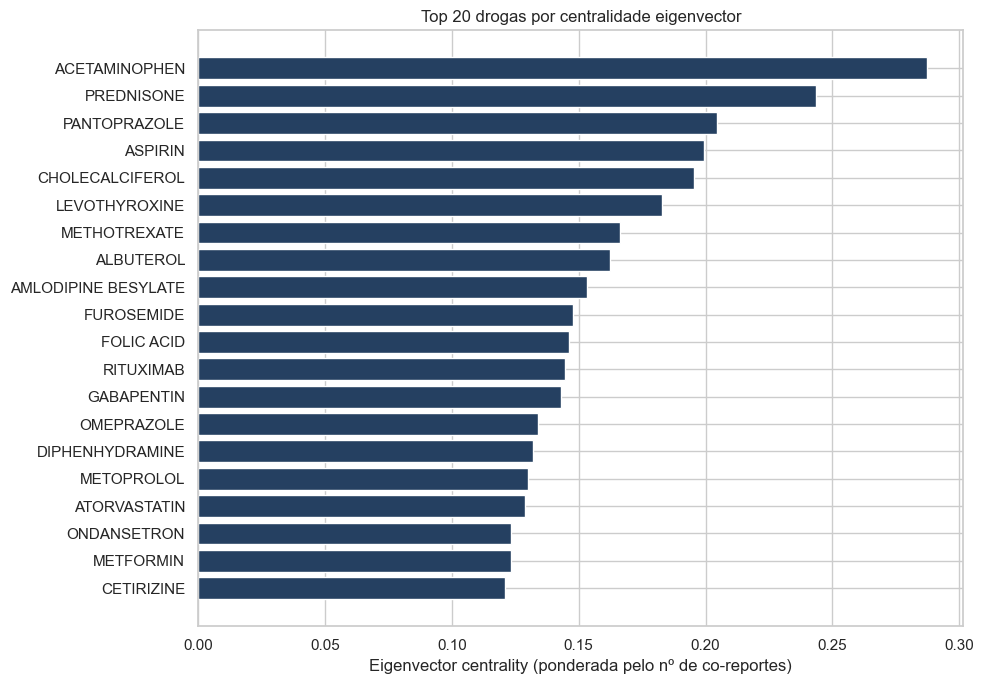

In [6]:
# Top 20 por eigenvector centrality
fig, ax = plt.subplots(figsize=(10, 7))
top = central.head(20).iloc[::-1]
ax.barh(top["drug"], top["eigenvector"], color="#254061")
ax.set_title("Top 20 drogas por centralidade eigenvector")
ax.set_xlabel("Eigenvector centrality (ponderada pelo nº de co-reportes)")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_centrality.png", bbox_inches="tight")
plt.show()

## 3. Comunidades (Louvain)

In [7]:
%time communities = detect_communities(g, seed=42)
central["community"] = central["drug"].map(communities)
n_comms = central["community"].nunique()
print(f"Comunidades detectadas: {n_comms}")

comm_sizes = central["community"].value_counts()
print(f"\nTamanhos das comunidades:")
print(comm_sizes.head(10))

CPU times: total: 109 ms
Wall time: 107 ms
Comunidades detectadas: 6

Tamanhos das comunidades:
community
4    104
2     44
5     32
1     10
0      6
3      3
Name: count, dtype: int64


In [8]:
# Inspecionar as 5 maiores comunidades
for comm_id in comm_sizes.head(5).index:
    members = central[central["community"] == comm_id].sort_values("eigenvector", ascending=False)
    print(f"\n=== Comunidade {comm_id} ({len(members)} drogas) ===")
    print("Top 10:", ", ".join(members["drug"].head(10).tolist()))


=== Comunidade 4 (104 drogas) ===
Top 10: PANTOPRAZOLE, ASPIRIN, CHOLECALCIFEROL, LEVOTHYROXINE, ALBUTEROL, AMLODIPINE BESYLATE, FUROSEMIDE, GABAPENTIN, OMEPRAZOLE, METOPROLOL

=== Comunidade 2 (44 drogas) ===
Top 10: PREDNISONE, METHOTREXATE, FOLIC ACID, RITUXIMAB, CETIRIZINE, METHYLPREDNISOLONE, IBUPROFEN, HYDROXYCHLOROQUINE, ADALIMUMAB, ASCORBIC ACID

=== Comunidade 5 (32 drogas) ===
Top 10: ONDANSETRON, DEXAMETHASONE, SULFAMETHOXAZOLE TRIMETHOPRIM, CYCLOPHOSPHAMIDE, ACYCLOVIR, LENALIDOMIDE, VINCRISTINE, DOXORUBICIN, VALACYCLOVIR, METOCLOPRAMIDE

=== Comunidade 1 (10 drogas) ===
Top 10: OXYCODONE, MORPHINE, TRAMADOL, ACETAMINOPHEN OXYCODONE, HYDROMORPHONE, ACETAMINOPHEN CODEINE, ACETAMINOPHEN HYDROCODONE BITARTRATE, FENTANYL, BUPRENORPHINE, OXYMORPHONE

=== Comunidade 0 (6 drogas) ===
Top 10: ACETAMINOPHEN, DIPHENHYDRAMINE, CHLORIDE, EPINEPHRINE, LIDOCAINE, HUMAN IMMUNOGLOBULIN G


## 4. Visualização estática do grafo (matplotlib)

Para o app vamos usar PyVis interativo; aqui um snapshot estático para o README.

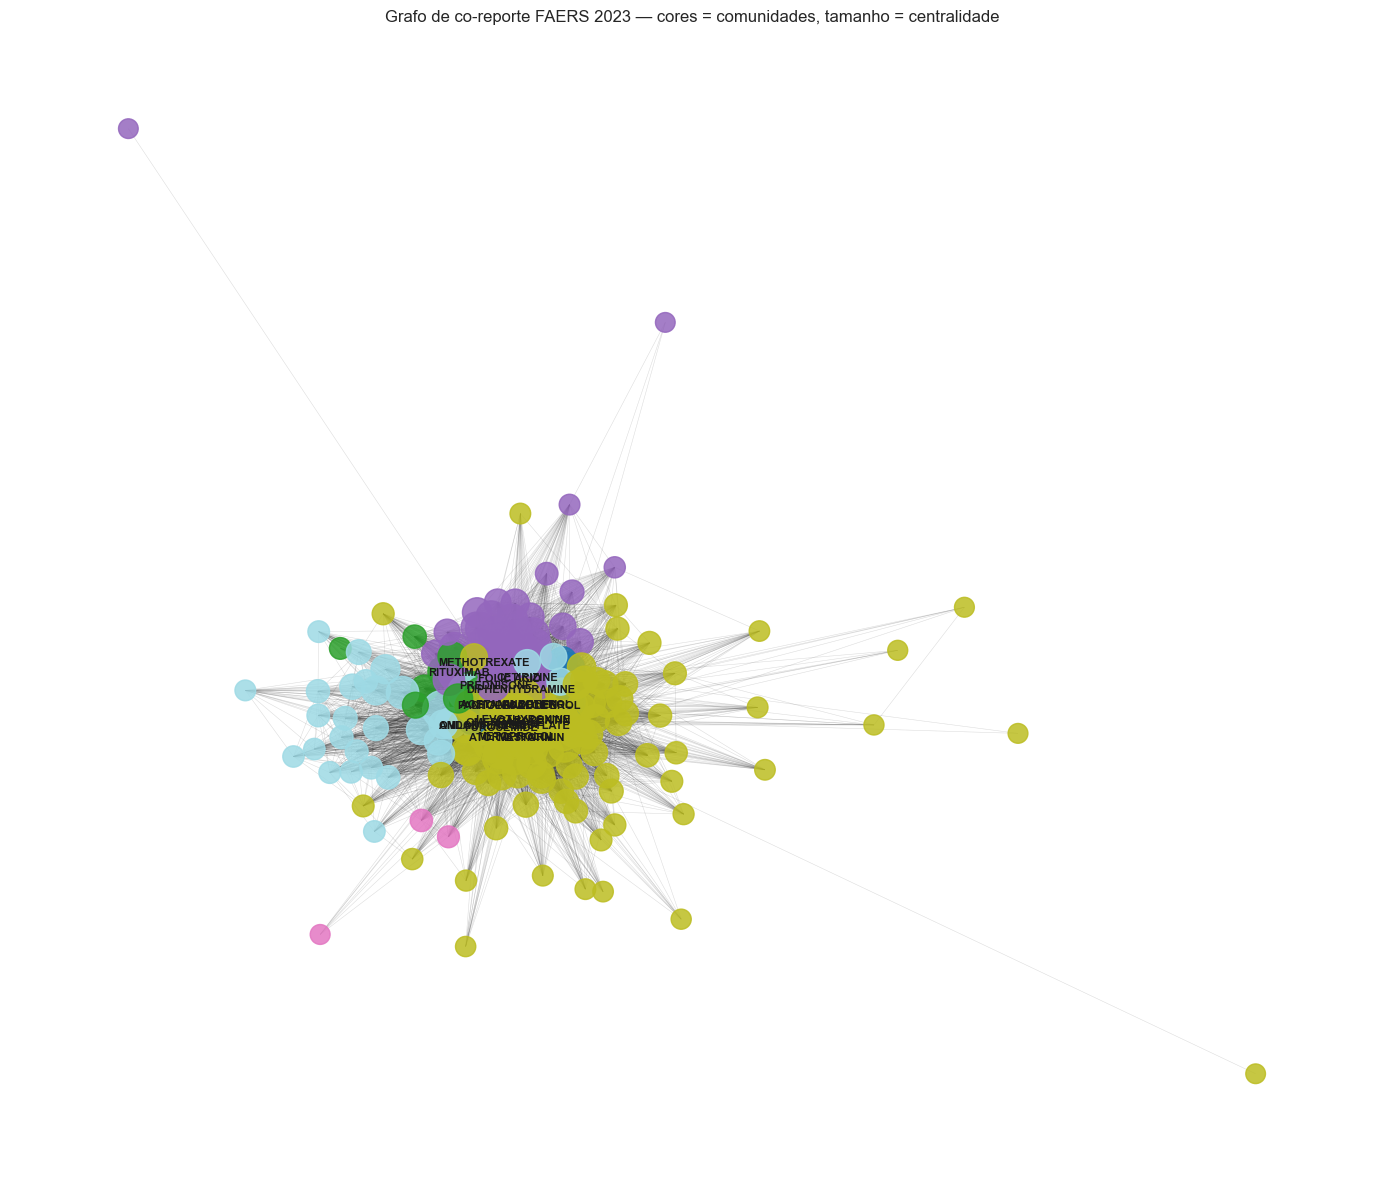

In [9]:
fig, ax = plt.subplots(figsize=(14, 12))

pos = nx.spring_layout(g, k=0.5, iterations=80, seed=42, weight="weight")
comm_colors = plt.cm.tab20(np.linspace(0, 1, n_comms))
node_colors = [comm_colors[communities[n]] for n in g.nodes]
node_sizes = [200 + 5000 * central.set_index("drug").loc[n, "eigenvector"] for n in g.nodes]

# arestas semi-transparentes
nx.draw_networkx_edges(g, pos, alpha=0.15, width=0.4, ax=ax)
nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)

# label só nos 20 nós mais centrais
top_labels = set(central.head(20)["drug"])
labels = {n: n for n in g.nodes if n in top_labels}
nx.draw_networkx_labels(g, pos, labels=labels, font_size=8, font_weight="bold", ax=ax)

ax.set_title("Grafo de co-reporte FAERS 2023 — cores = comunidades, tamanho = centralidade", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_network.png", bbox_inches="tight", dpi=120)
plt.show()

## 5. Pares com co-reporte mais alto

In [10]:
top_pairs = edges.head(15)
print("Top 15 pares de drogas mais frequentemente co-reportadas:")
top_pairs

Top 15 pares de drogas mais frequentemente co-reportadas:


,source,target,weight
0,ACETAMINOPHEN,DIPHENHYDRAMINE,11093
1,ACETAMINOPHEN HYDROCODONE BITARTRATE,ACETAMINOPHEN OXYCODONE,10534
2,PREDNISONE,RITUXIMAB,10379
3,METHOTREXATE,PREDNISONE,9668
4,CYCLOPHOSPHAMIDE,DOXORUBICIN,9552
5,FOLIC ACID,METHOTREXATE,9085
6,CYCLOPHOSPHAMIDE,VINCRISTINE,8683
7,ACETAMINOPHEN,PREDNISONE,8126
8,ACETAMINOPHEN,PANTOPRAZOLE,7830
9,CYCLOPHOSPHAMIDE,RITUXIMAB,7791


## 6. Salvar artefatos para o dashboard

In [11]:
edges.to_parquet(PROCESSED / "network_edges_2023.parquet", index=False)
central.to_parquet(PROCESSED / "network_centrality_2023.parquet", index=False)
print("✓ Edges e centralidade salvos.")

✓ Edges e centralidade salvos.


## 7. Conclusões

- **Hubs** identificados pela centralidade eigenvector tendem a ser drogas usadas em polifarmácia (analgésicos comuns, vitaminas, AAS).
- **Comunidades** geralmente refletem **classes terapêuticas** (oncológicos, biológicos para reumatologia, drogas cardiovasculares) — emergência espontânea de estrutura clínica.
- Pares com co-reporte alto incluem combinações conhecidas (paracetamol+opioide) e indicações concorrentes (anti-hipertensivos+estatinas).